Task_6: K_Mean Clustering

--- PART 1: Loading and Preparing Real-World Data ---
Dataset 'Mall_Customers.csv' loaded successfully.

First 5 rows of the dataset:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4

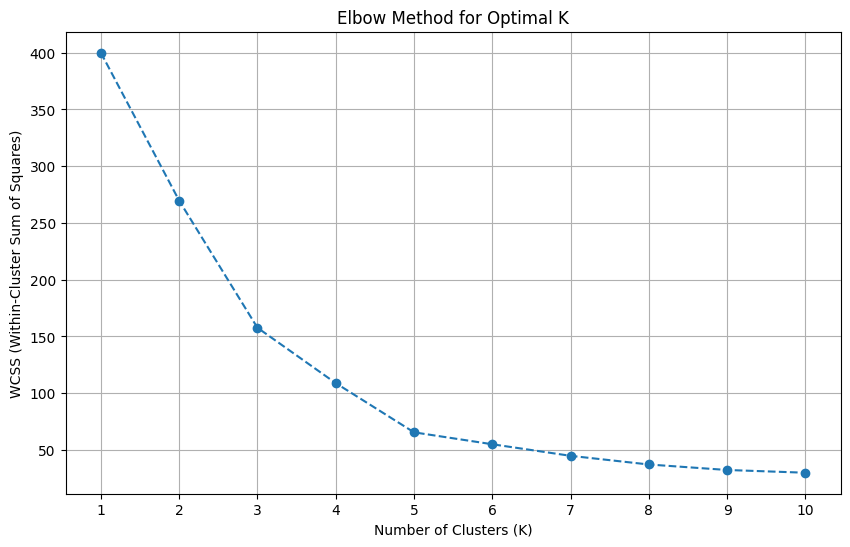

Part 2: Elbow Method plot displayed. Look for the 'elbow' point where the decrease in WCSS starts to slow down significantly.

--- PART 3: Determining Optimal K using Silhouette Score ---
  For K=2, Silhouette Score: 0.3213
  For K=3, Silhouette Score: 0.4666
  For K=4, Silhouette Score: 0.4939
  For K=5, Silhouette Score: 0.5547
  For K=6, Silhouette Score: 0.5399
  For K=7, Silhouette Score: 0.5281
  For K=8, Silhouette Score: 0.4552
  For K=9, Silhouette Score: 0.4571
  For K=10, Silhouette Score: 0.4432
Silhouette Scores calculated.


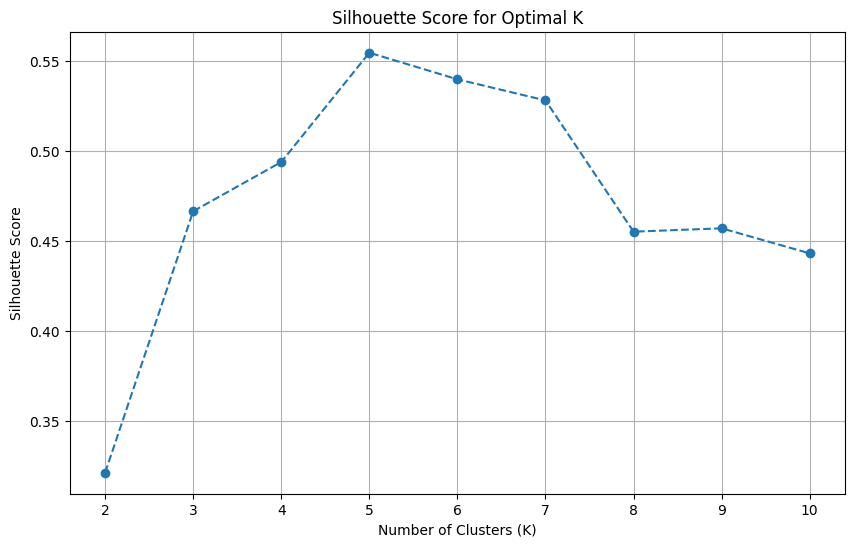

Part 3: Silhouette Score plot displayed. Look for the peak (highest score) to identify the best K.
Based on observation of both plots (Elbow and Silhouette), K=5 is often a good choice for this dataset.

--- PART 4: Applying K-Means with Optimal K and Analyzing Clusters ---
Proceeding with optimal K = 5 for final clustering.

Cluster labels assigned to customers. First 5 rows with new 'Cluster' column:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   Cluster  
0        4  
1        2  
2        4  
3        2  
4        4  

Analyzing average characteristics for each of the 5 clusters:
        

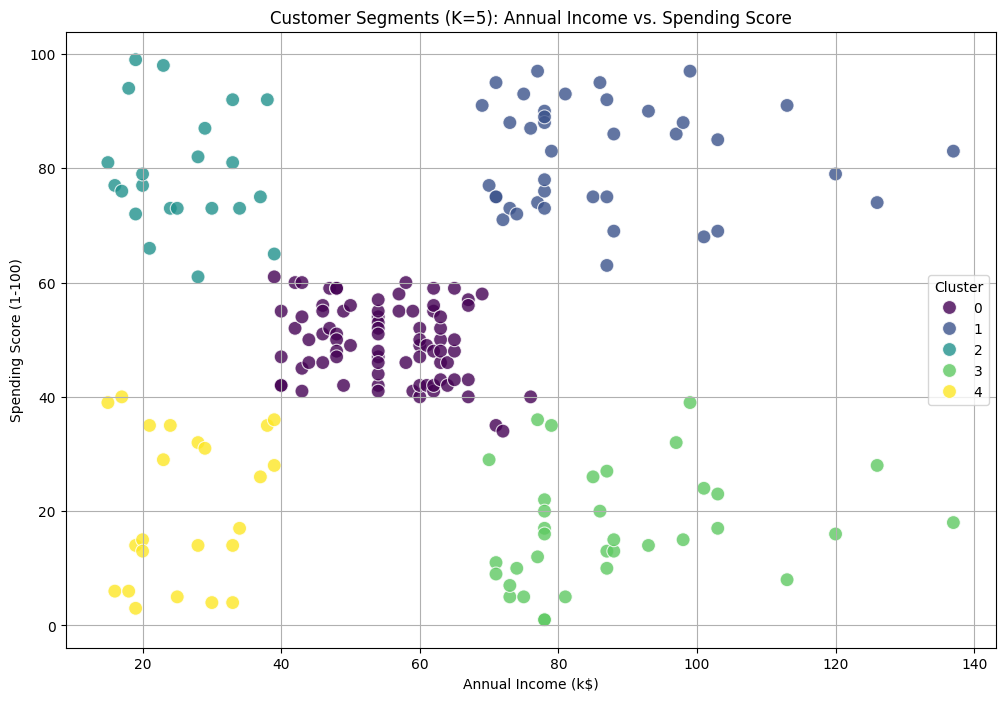


Part 5: 2D visualization displayed. Each color represents a different customer segment based on Income and Spending.

--- PART 6: Visualizing Clusters in 3D Space ---


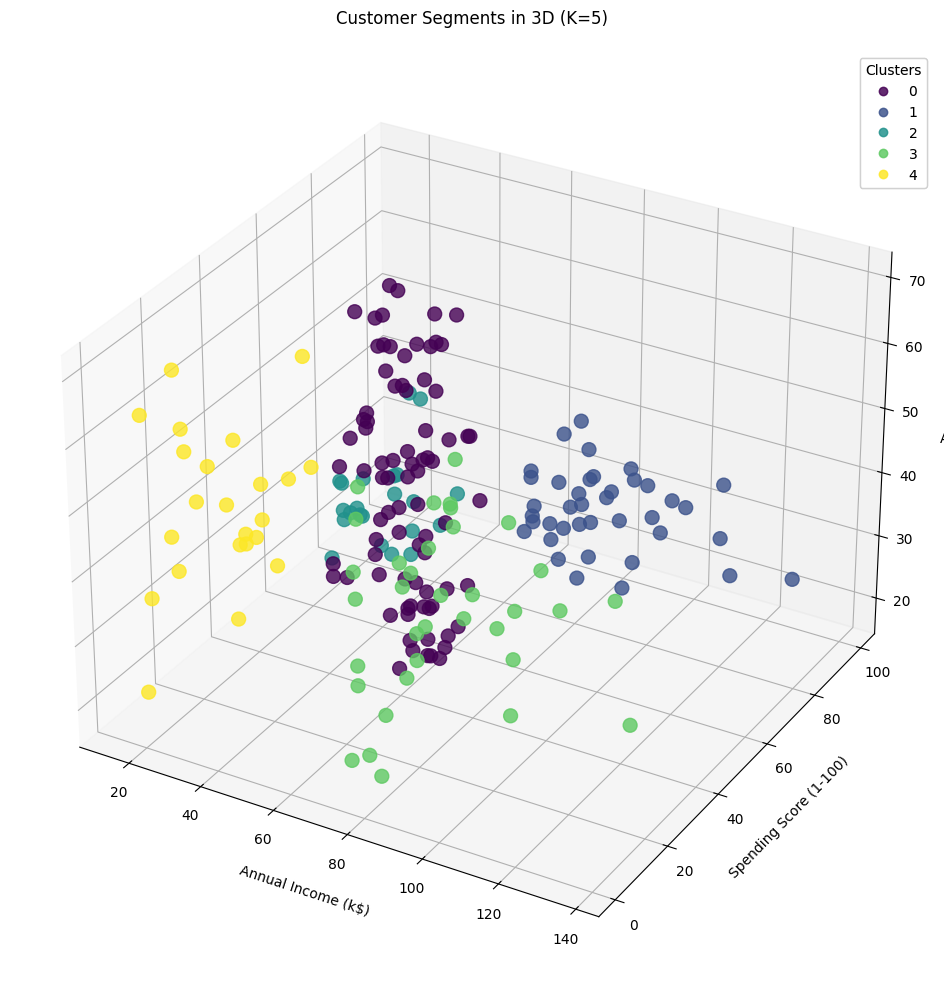


Part 6: 3D visualization displayed. This plot helps in understanding segments across three dimensions.

--- All tasks completed! ---


In [ ]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from mpl_toolkits.mplot3d import Axes3D # For 3D plotting

# --- PART 1: Load and Prepare Data (Real-world CSV) ---

print("--- PART 1: Loading and Preparing Real-World Data ---")

# IMPORTANT: Replace 'Mall_Customers.csv' with the actual path to your dataset file.
# Make sure this file is in the same directory as your Python script,
# or provide the full path like 'C:/Users/YourUser/Documents/Mall_Customers.csv'
try:
    df = pd.read_csv('Mall_Customers.csv')
    print("Dataset 'Mall_Customers.csv' loaded successfully.")
except FileNotFoundError:
    print("Error: 'Mall_Customers.csv' not found.")
    print("Please ensure the file is in the same directory as your script, or provide the full path.")
    # Exit or handle the error appropriately if the file isn't found
    exit()

# Display the first few rows of the dataset to understand its structure
print("\nFirst 5 rows of the dataset:")
print(df.head())

# Display basic information about the dataset (columns, non-null counts, data types)
print("\nDataset Information:")
df.info()

# Check for any missing values
print("\nMissing values in each column:")
print(df.isnull().sum())

# Select features for clustering
# We'll use 'Annual Income (k$)' and 'Spending Score (1-100)' as they are typically
# the most impactful for customer segmentation in this dataset.
print("\nSelecting 'Annual Income (k$)' and 'Spending Score (1-100)' for clustering...")
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# Scale the data
# StandardScaler transforms the data to have a mean of 0 and a standard deviation of 1.
# This is crucial because K-Means uses distance calculations, and unscaled features
# with larger numerical ranges would disproportionately influence the clustering.
print("Scaling the selected features...")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Features scaled. First 5 rows of scaled data (example):")
print(X_scaled[:5])

print("\nPart 1: Data loading and preparation complete. 'df' (original data) and 'X_scaled' (features for clustering) are ready.")

# --- PART 2: Determine Optimal Number of Clusters (K) using Elbow Method ---

print("\n--- PART 2: Determining Optimal K using Elbow Method ---")

wcss = [] # Within-Cluster Sum of Squares (measures compactness of clusters)

# Iterate K from 1 to 10 to find the best number of clusters
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i,  # Number of clusters for this iteration
                    init='k-means++', # Smart way to initialize centroids to speed up convergence
                    random_state=42,  # Ensures reproducibility of results
                    n_init=10)        # Runs K-Means 10 times with different centroid seeds and picks the best
    kmeans.fit(X_scaled)              # Train the K-Means model on the scaled data
    wcss.append(kmeans.inertia_)      # 'inertia_' attribute holds the WCSS value

print("WCSS values calculated for K from 1 to 10.")

# Plotting the Elbow Method graph
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.xticks(range(1, 11)) # Ensure integer ticks on x-axis
plt.grid(True)
plt.show()

print("Part 2: Elbow Method plot displayed. Look for the 'elbow' point where the decrease in WCSS starts to slow down significantly.")

# --- PART 3: Determine Optimal Number of Clusters (K) using Silhouette Score ---

print("\n--- PART 3: Determining Optimal K using Silhouette Score ---")

silhouette_scores = []

# Silhouette score requires at least 2 clusters
for i in range(2, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    score = silhouette_score(X_scaled, kmeans.labels_) # Calculate the silhouette score
    silhouette_scores.append(score)
    print(f"  For K={i}, Silhouette Score: {score:.4f}")

print("Silhouette Scores calculated.")

# Plotting the Silhouette Score graph
plt.figure(figsize=(10, 6))
plt.plot(range(2, 11), silhouette_scores, marker='o', linestyle='--')
plt.title('Silhouette Score for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.xticks(range(2, 11)) # Ensure integer ticks on x-axis
plt.grid(True)
plt.show()

print("Part 3: Silhouette Score plot displayed. Look for the peak (highest score) to identify the best K.")
print("Based on observation of both plots (Elbow and Silhouette), K=5 is often a good choice for this dataset.")

# --- PART 4: Apply K-Means with Optimal K and Analyze Clusters ---

print("\n--- PART 4: Applying K-Means with Optimal K and Analyzing Clusters ---")

# Based on typical Mall Customers dataset analysis and observing elbow/silhouette plots,
# K=5 often appears as a reasonable optimal number of clusters.
optimal_k = 5
print(f"Proceeding with optimal K = {optimal_k} for final clustering.")

# Apply K-Means with the chosen optimal number of clusters
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
# Fit the model and predict the cluster labels for each data point
df['Cluster'] = kmeans.fit_predict(X_scaled)

print(f"\nCluster labels assigned to customers. First 5 rows with new 'Cluster' column:")
print(df.head())

# Analyze the characteristics of each cluster
# Group by the 'Cluster' column and calculate the mean of relevant features
print(f"\nAnalyzing average characteristics for each of the {optimal_k} clusters:")
# Including 'Age' here to provide more context to the clusters, even if not used for clustering directly
cluster_means = df.groupby('Cluster')[['Annual Income (k$)', 'Spending Score (1-100)', 'Age']].mean()
print(cluster_means)

# Get the count of customers in each cluster
print("\nNumber of customers in each cluster:")
print(df['Cluster'].value_counts().sort_index())

print("\nPart 4: Final clustering and detailed cluster analysis complete.")

# --- PART 5: Visualize Clusters in 2D Space ---

print("\n--- PART 5: Visualizing Clusters in 2D Space ---")

plt.figure(figsize=(12, 8))
# Use seaborn's scatterplot for an attractive 2D visualization
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', # Features on x and y axes
                hue='Cluster',                                  # Color points based on their assigned cluster
                data=df,                                        # Use the DataFrame with cluster labels
                palette='viridis',                              # Color scheme for the clusters
                s=100,                                          # Size of the data points
                alpha=0.8,                                      # Transparency of the points
                legend='full')                                  # Display the full legend for cluster colors

plt.title(f'Customer Segments (K={optimal_k}): Annual Income vs. Spending Score')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.grid(True)
plt.show()

print("\nPart 5: 2D visualization displayed. Each color represents a different customer segment based on Income and Spending.")

# --- PART 6: Visualize Clusters in 3D Space (incorporating Age) ---

print("\n--- PART 6: Visualizing Clusters in 3D Space ---")

# To visualize in 3D, we'll use 'Annual Income', 'Spending Score', and 'Age'.
# We will use the 'Cluster' labels derived from the 2-feature clustering for consistency.
# If you wanted clustering to be explicitly based on 3 features (Income, Spending, Age),
# you would need to re-run the entire K-Means process (Elbow, Silhouette, final clustering)
# on the 3D scaled data. For visualization, we simply use existing cluster labels.

# Prepare the data for 3D visualization (using original unscaled values for axis labels)
# It's good practice to align the features with those used in clustering for clearer interpretation.
X_3d_viz = df[['Annual Income (k$)', 'Spending Score (1-100)', 'Age']]

fig = plt.figure(figsize=(14, 12)) # Create a figure for the 3D plot
ax = fig.add_subplot(111, projection='3d') # Add a 3D subplot

# Create the 3D scatter plot
scatter = ax.scatter(X_3d_viz['Annual Income (k$)'],
                     X_3d_viz['Spending Score (1-100)'],
                     X_3d_viz['Age'],
                     c=df['Cluster'], # Color points by their assigned cluster
                     cmap='viridis',  # Color map
                     s=100,           # Marker size
                     alpha=0.8)       # Transparency

# Set labels for the axes
ax.set_xlabel('Annual Income (k$)', labelpad=10) # labelpad adds padding to the label
ax.set_ylabel('Spending Score (1-100)', labelpad=10)
ax.set_zlabel('Age', labelpad=10)
ax.set_title(f'Customer Segments in 3D (K={optimal_k})', pad=20) # pad adds padding to the title

# Create a legend for the clusters
legend1 = ax.legend(*scatter.legend_elements(), title="Clusters")
ax.add_artist(legend1) # Add the legend to the plot

# Optional: Adjust view angle for better perspective
# ax.view_init(elev=20, azim=-120) # elev: elevation angle, azim: azimuthal angle

plt.show()

print("\nPart 6: 3D visualization displayed. This plot helps in understanding segments across three dimensions.")
print("\n--- All tasks completed! ---")

# New Section

DBSCAN Clustering: Comparison BTW K_Mean & DBSCAN

--- PART 1: Loading and Preparing Real-World Data ---
Dataset 'Mall_Customers.csv' loaded successfully.

First 5 rows of the dataset:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4

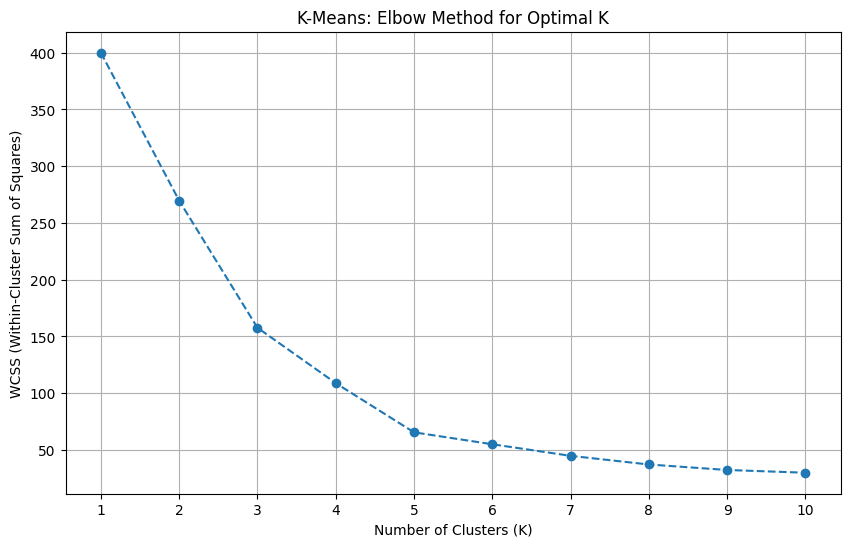

K-Means: Elbow Method plot displayed.

--- PART 3: K-Means: Determining Optimal K using Silhouette Score ---
  K-Means: For K=2, Silhouette Score: 0.3213
  K-Means: For K=3, Silhouette Score: 0.4666
  K-Means: For K=4, Silhouette Score: 0.4939
  K-Means: For K=5, Silhouette Score: 0.5547
  K-Means: For K=6, Silhouette Score: 0.5399
  K-Means: For K=7, Silhouette Score: 0.5281
  K-Means: For K=8, Silhouette Score: 0.4552
  K-Means: For K=9, Silhouette Score: 0.4571
  K-Means: For K=10, Silhouette Score: 0.4432


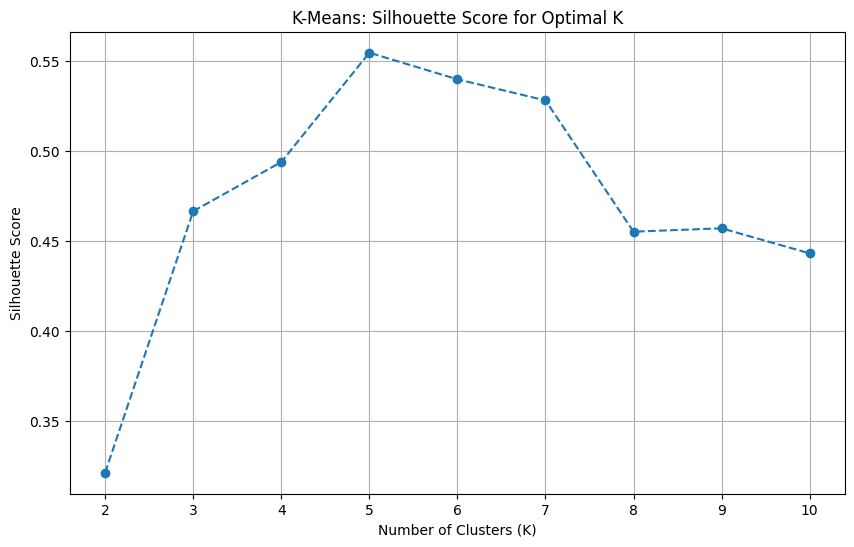

K-Means: Silhouette Score plot displayed. (Optimal K for K-Means often around 5 for this dataset).

--- PART 4: K-Means: Applying Optimal K and Analyzing Clusters ---
K-Means: Proceeding with optimal K = 5 for final clustering.

K-Means: Cluster labels assigned. First 5 rows with new 'KMeans_Cluster' column:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   KMeans_Cluster  
0               4  
1               2  
2               4  
3               2  
4               4  

K-Means: Average characteristics for each of the 5 clusters:
                Annual Income (k$)  Spending Score (1-100)     

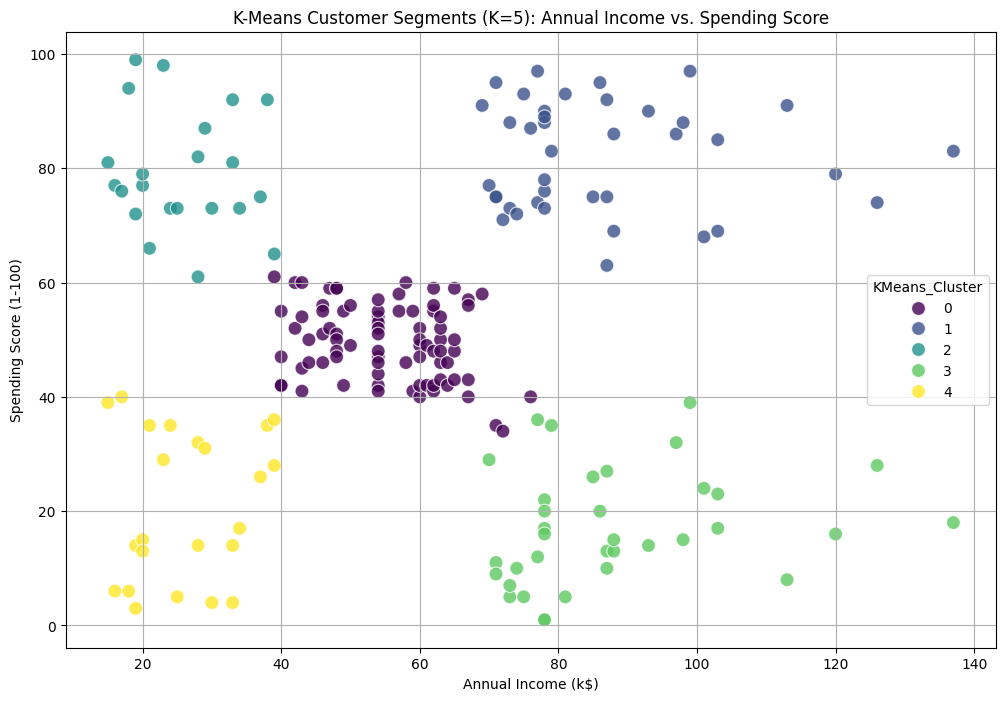

K-Means 2D visualization displayed.

--- PART 8: Visualizing DBSCAN Clusters in 2D Space ---


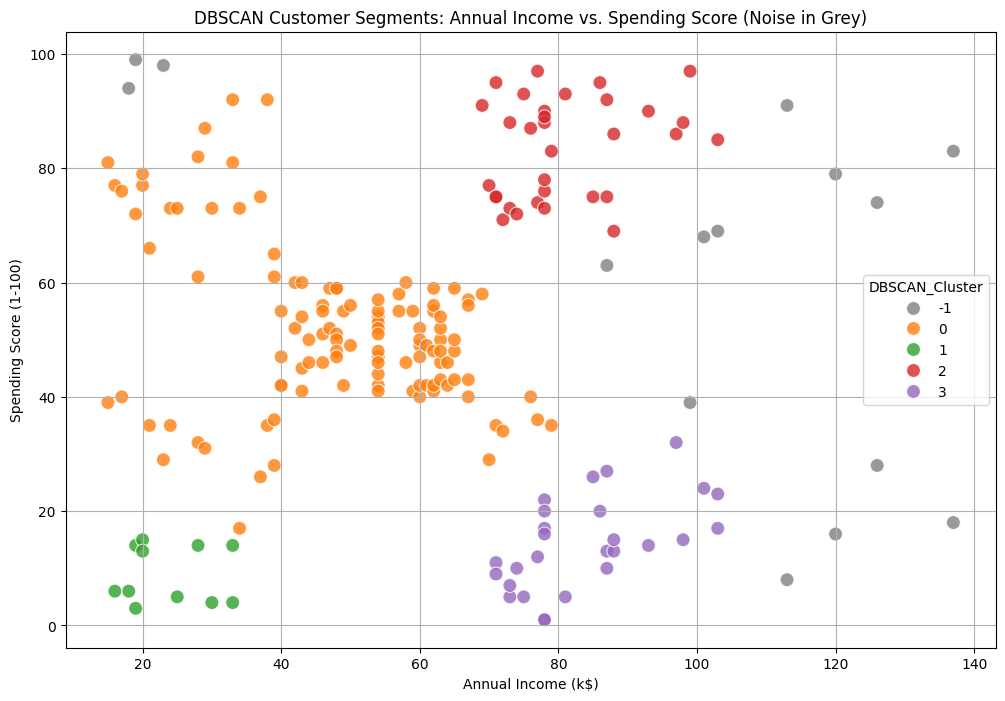


Part 8: DBSCAN 2D visualization displayed (noise points in grey).

--- PART 9: Visualizing K-Means Clusters in 3D Space ---


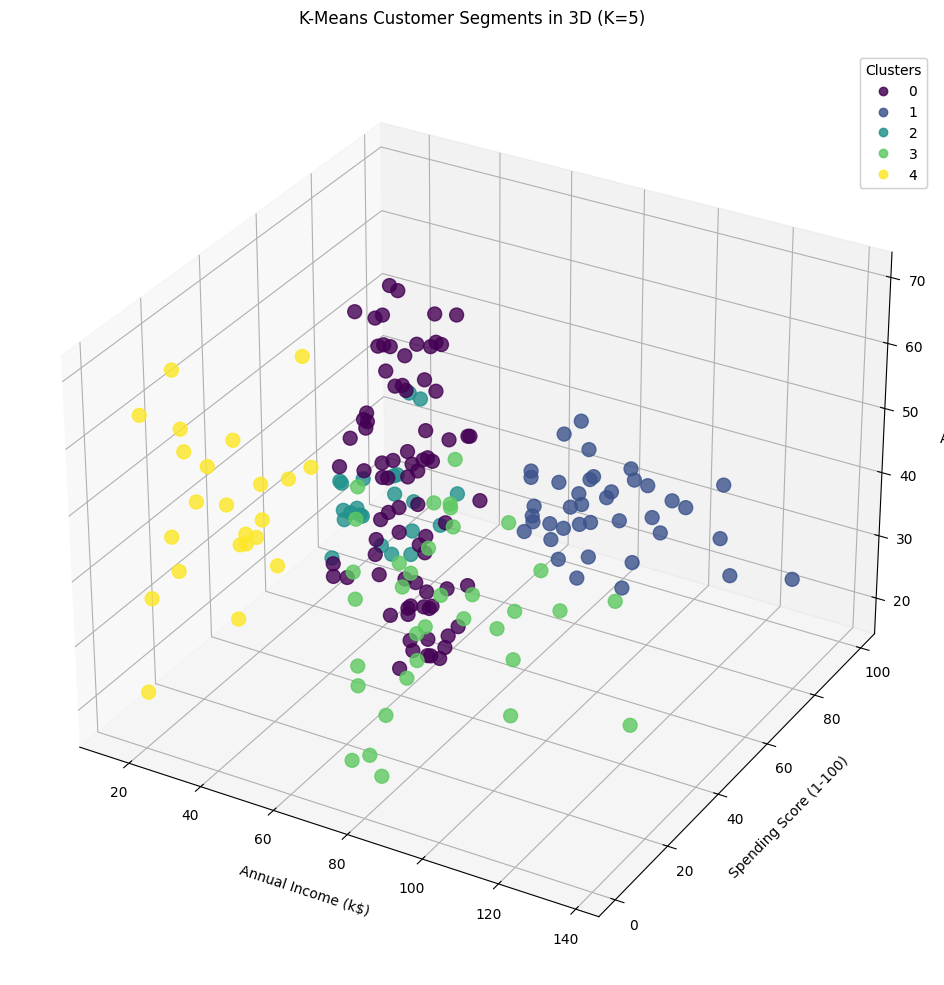

K-Means 3D visualization displayed.

--- PART 10: Visualizing DBSCAN Clusters in 3D Space (Corrected) ---


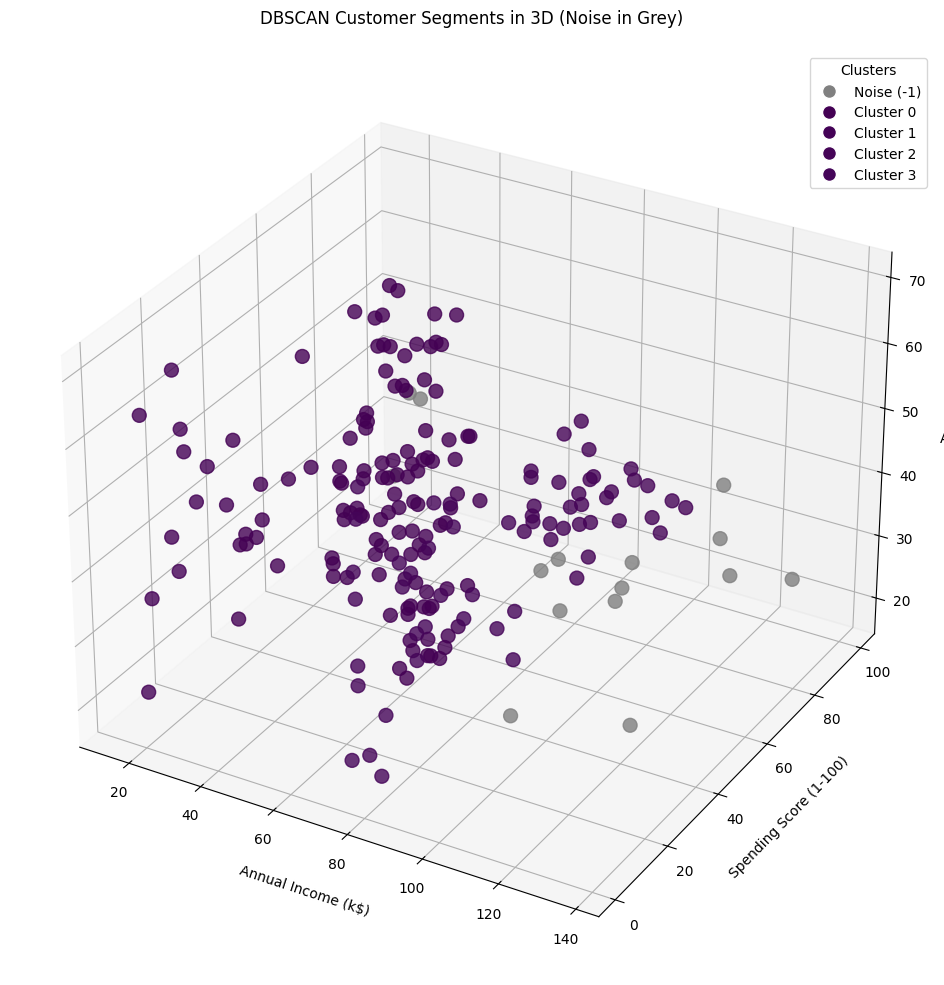


Part 10: DBSCAN 3D visualization displayed (noise points in grey).


In [ ]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from mpl_toolkits.mplot3d import Axes3D # For 3D plotting
from sklearn.cluster import DBSCAN # New import for DBSCAN

# --- PART 1: Load and Prepare Data (Real-world CSV) ---

print("--- PART 1: Loading and Preparing Real-World Data ---")

# IMPORTANT: Replace 'Mall_Customers.csv' with the actual path to your dataset file.
try:
    df = pd.read_csv('/content/Mall_Customers.csv')
    print("Dataset 'Mall_Customers.csv' loaded successfully.")
except FileNotFoundError:
    print("Error: 'Mall_Customers.csv' not found.")
    print("Please ensure the file is in the same directory as your script, or provide the full path.")
    exit()

print("\nFirst 5 rows of the dataset:")
print(df.head())

print("\nDataset Information:")
df.info()

print("\nMissing values in each column:")
print(df.isnull().sum())

# Select features for clustering - using the same features as K-Means for fair comparison
print("\nSelecting 'Annual Income (k$)' and 'Spending Score (1-100)' for clustering...")
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# Scale the data - essential for both K-Means and DBSCAN as they are distance-based algorithms
print("Scaling the selected features...")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Features scaled. First 5 rows of scaled data (example):")
print(X_scaled[:5])

print("\nPart 1: Data loading and preparation complete.")

# --- PART 2: K-Means: Determine Optimal Number of Clusters (K) using Elbow Method ---
# This part is identical to the previous K-Means analysis
print("\n--- PART 2: K-Means: Determining Optimal K using Elbow Method ---")
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('K-Means: Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()
print("K-Means: Elbow Method plot displayed.")

# --- PART 3: K-Means: Determine Optimal Number of Clusters (K) using Silhouette Score ---
# This part is identical to the previous K-Means analysis
print("\n--- PART 3: K-Means: Determining Optimal K using Silhouette Score ---")
silhouette_scores = []
for i in range(2, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    score = silhouette_score(X_scaled, kmeans.labels_)
    silhouette_scores.append(score)
    print(f"  K-Means: For K={i}, Silhouette Score: {score:.4f}")
plt.figure(figsize=(10, 6))
plt.plot(range(2, 11), silhouette_scores, marker='o', linestyle='--')
plt.title('K-Means: Silhouette Score for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.xticks(range(2, 11))
plt.grid(True)
plt.show()
print("K-Means: Silhouette Score plot displayed. (Optimal K for K-Means often around 5 for this dataset).")

# --- PART 4: K-Means: Apply Optimal K and Analyze Clusters ---
# This part is identical to the previous K-Means analysis
print("\n--- PART 4: K-Means: Applying Optimal K and Analyzing Clusters ---")
optimal_k_kmeans = 5 # Based on previous analysis for K-Means
print(f"K-Means: Proceeding with optimal K = {optimal_k_kmeans} for final clustering.")
kmeans_final = KMeans(n_clusters=optimal_k_kmeans, init='k-means++', random_state=42, n_init=10)
df['KMeans_Cluster'] = kmeans_final.fit_predict(X_scaled) # Store K-Means clusters in a new column

print(f"\nK-Means: Cluster labels assigned. First 5 rows with new 'KMeans_Cluster' column:")
print(df.head())

print(f"\nK-Means: Average characteristics for each of the {optimal_k_kmeans} clusters:")
kmeans_cluster_means = df.groupby('KMeans_Cluster')[['Annual Income (k$)', 'Spending Score (1-100)', 'Age']].mean()
print(kmeans_cluster_means)

print("\nK-Means: Number of customers in each cluster:")
print(df['KMeans_Cluster'].value_counts().sort_index())
print("\nPart 4: K-Means clustering and analysis complete.")


# --- PART 5: Apply DBSCAN Clustering ---

print("\n--- PART 5: Applying DBSCAN Clustering ---")

# DBSCAN requires two main parameters:
# 1. eps (epsilon): The maximum distance between two samples for one to be considered as in the neighborhood of the other.
#    A common way to estimate eps is using a k-distance graph (usually k=min_samples-1).
#    For this dataset and after scaling, a value around 0.3 to 0.5 often works.
# 2. min_samples: The number of samples (or total weight) in a neighborhood for a point to be considered as a core point.
#    A typical rule of thumb for min_samples is 2 * number_of_features. Here, 2 features, so 4.

# Let's try some common values for the scaled Mall Customers data
# You might need to experiment with these values to get good clusters for your specific data.
eps_val = 0.4 # Adjust this based on data density
min_samples_val = 5 # Adjust this (e.g., 2 * num_features, or slightly higher)

print(f"DBSCAN: Applying DBSCAN with eps={eps_val} and min_samples={min_samples_val}")

dbscan = DBSCAN(eps=eps_val, min_samples=min_samples_val)
dbscan_labels = dbscan.fit_predict(X_scaled) # Apply DBSCAN to the scaled data

df['DBSCAN_Cluster'] = dbscan_labels # Add DBSCAN cluster labels to the DataFrame

print("\nDBSCAN: Cluster labels assigned. First 5 rows with new 'DBSCAN_Cluster' column:")
print(df.head())

print("\nDBSCAN: Number of customers in each cluster (Note: -1 indicates Noise points):")
print(df['DBSCAN_Cluster'].value_counts().sort_index())

num_dbscan_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
num_noise_points = list(dbscan_labels).count(-1)

print(f"\nDBSCAN found {num_dbscan_clusters} clusters and identified {num_noise_points} noise points.")
print("\nPart 5: DBSCAN clustering complete.")

# --- PART 6: Comparison and Analysis of K-Means vs. DBSCAN ---

print("\n--- PART 6: Comparison and Analysis of K-Means vs. DBSCAN ---")

print("\nKey Differences Summary:")
print(f"- K-Means found {optimal_k_kmeans} clusters and assigned every point to a cluster.")
print(f"- DBSCAN found {num_dbscan_clusters} clusters and identified {num_noise_points} points as noise.")

print("\nVisual Inspection of Cluster Characteristics (K-Means vs. DBSCAN):")
print("\nK-Means Cluster Means:")
print(kmeans_cluster_means)
print("\nDBSCAN Cluster Means (excluding noise):")
# Filter out noise points (-1) for mean calculation
dbscan_cluster_means = df[df['DBSCAN_Cluster'] != -1].groupby('DBSCAN_Cluster')[['Annual Income (k$)', 'Spending Score (1-100)', 'Age']].mean()
print(dbscan_cluster_means)

print("\nInterpretation of Differences:")
print("K-Means forces all data points into predefined K clusters, resulting in potentially 'stretched' or less intuitive clusters if the data has irregular shapes or outliers.")
print("DBSCAN, being density-based, can discover clusters of arbitrary shapes and sizes, and importantly, it can identify outliers (noise points).")
print("If the mall customer data truly contains isolated individuals or groups that don't fit into dense segments, DBSCAN might provide a more realistic segmentation by labeling them as noise.")
print("The number of clusters found by DBSCAN depends heavily on 'eps' and 'min_samples'. Different choices can lead to very different results.")

print("\nPart 6: Comparison and analysis complete.")


# --- PART 7: Visualize K-Means Clusters in 2D Space ---

print("\n--- PART 7: Visualizing K-Means Clusters in 2D Space ---")
plt.figure(figsize=(12, 8))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)',
                hue='KMeans_Cluster', data=df,
                palette='viridis', s=100, alpha=0.8, legend='full')
plt.title(f'K-Means Customer Segments (K={optimal_k_kmeans}): Annual Income vs. Spending Score')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.grid(True)
plt.show()
print("K-Means 2D visualization displayed.")

# --- PART 8: Visualize DBSCAN Clusters in 2D Space ---

print("\n--- PART 8: Visualizing DBSCAN Clusters in 2D Space ---")

plt.figure(figsize=(12, 8))
# Create a custom palette to highlight noise points (-1) in a distinct color (e.g., black or grey)
# Get unique cluster labels from DBSCAN
dbscan_unique_labels = sorted(df['DBSCAN_Cluster'].unique())
# Create a color map that maps -1 to black/grey and other clusters to a color palette
colors = sns.color_palette('tab10', n_colors=len(dbscan_unique_labels)) # Use a palette with enough colors
# Ensure there's a distinct color for noise (-1)
if -1 in dbscan_unique_labels:
    noise_color_idx = dbscan_unique_labels.index(-1)
    colors[noise_color_idx] = (0.5, 0.5, 0.5) # Grey color for noise
    # Adjust other colors to avoid conflict if necessary (optional)
    # Or just use a direct dictionary mapping for simplicity if colors are known

sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)',
                hue='DBSCAN_Cluster', data=df,
                palette={label: color for label, color in zip(dbscan_unique_labels, colors)}, # Use the custom palette
                s=100, alpha=0.8, legend='full')

plt.title(f'DBSCAN Customer Segments: Annual Income vs. Spending Score (Noise in Grey)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.grid(True)
plt.show()

print("\nPart 8: DBSCAN 2D visualization displayed (noise points in grey).")

# --- PART 9: Visualize K-Means Clusters in 3D Space ---
# This is identical to the previous K-Means 3D visualization
print("\n--- PART 9: Visualizing K-Means Clusters in 3D Space ---")
X_3d_viz = df[['Annual Income (k$)', 'Spending Score (1-100)', 'Age']]
fig = plt.figure(figsize=(14, 12))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(X_3d_viz['Annual Income (k$)'], X_3d_viz['Spending Score (1-100)'], X_3d_viz['Age'],
                     c=df['KMeans_Cluster'], cmap='viridis', s=100, alpha=0.8)
ax.set_xlabel('Annual Income (k$)', labelpad=10)
ax.set_ylabel('Spending Score (1-100)', labelpad=10)
ax.set_zlabel('Age', labelpad=10)
ax.set_title(f'K-Means Customer Segments in 3D (K={optimal_k_kmeans})', pad=20)
legend1 = ax.legend(*scatter.legend_elements(), title="Clusters")
ax.add_artist(legend1)
plt.show()
print("K-Means 3D visualization displayed.")


# --- PART 10: Visualize DBSCAN Clusters in 3D Space ---


print("\n--- PART 10: Visualizing DBSCAN Clusters in 3D Space (Corrected) ---")

fig = plt.figure(figsize=(14, 12))
ax = fig.add_subplot(111, projection='3d')

# Prepare the cluster labels for colormapping in 3D
# Map DBSCAN_Cluster labels to numerical values suitable for colormapping
# We want -1 (noise) to be a distinct color, and actual clusters (0, 1, 2...) to be colored by a palette.

# Get unique labels and map them to integers starting from 0 (excluding -1 for clusters)
dbscan_labels_numeric = df['DBSCAN_Cluster'].copy()
unique_clusters = sorted([l for l in dbscan_labels_numeric.unique() if l != -1])
num_actual_clusters = len(unique_clusters)

# Create a custom colormap
from matplotlib.colors import ListedColormap
# Define colors for actual clusters (e.g., using 'viridis' colors)
cluster_colors = plt.cm.viridis(range(num_actual_clusters))
# Define color for noise (grey)
noise_color = (0.5, 0.5, 0.5, 1) # RGBA for grey
# Combine noise color and cluster colors to create the full list of colors
all_colors = []
color_map_dict = {}
current_color_idx = 0

# Assign colors to clusters (0, 1, 2...)
for cluster_id in unique_clusters:
    color_map_dict[cluster_id] = cluster_colors[current_color_idx]
    current_color_idx += 1

# Assign color to noise (-1)
if -1 in dbscan_labels_numeric.unique():
    color_map_dict[-1] = noise_color

# Create a numerical array that maps each original label to its corresponding color index
# This is a bit more complex. A simpler way for ax.scatter is to build a list of colors directly.

# Convert cluster labels to a list of RGBA colors for each point
point_colors = [color_map_dict[label] for label in dbscan_labels_numeric]


# Create the 3D scatter plot
# Pass the list of RGBA colors directly to the 'c' argument
scatter = ax.scatter(X_3d_viz['Annual Income (k$)'],
                     X_3d_viz['Spending Score (1-100)'],
                     X_3d_viz['Age'],
                     c=point_colors, # Pass the list of RGBA colors
                     s=100, alpha=0.8)

ax.set_xlabel('Annual Income (k$)', labelpad=10)
ax.set_ylabel('Spending Score (1-100)', labelpad=10)
ax.set_zlabel('Age', labelpad=10)
ax.set_title(f'DBSCAN Customer Segments in 3D (Noise in Grey)', pad=20)

# Create a legend
# The legend for direct color arrays requires a bit more manual setup
# Create custom handles for the legend
from matplotlib.lines import Line2D
legend_elements = []
for label in dbscan_unique_labels:
    color = color_map_dict[label]
    display_label = f'Cluster {label}' if label != -1 else 'Noise (-1)'
    legend_elements.append(Line2D([0], [0], marker='o', color='w', label=display_label,
                                  markerfacecolor=color, markersize=10))

ax.legend(handles=legend_elements, title="Clusters")

plt.show()

print("\nPart 10: DBSCAN 3D visualization displayed (noise points in grey).")